In [23]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from Utils.TrainUtils import get_device, build_dataloaders, train_model, compute_pos_weight_from_loader

from Models.FraudModel import TransformerFraudModel, GatedTransformerFraudModel, AEAttentionPoolingTransformerFraudModel, LastTokenMLP

from Utils.NormalizationUtils import fit_feature_normalizer, apply_feature_normalizer

In [ ]:
# Skip if the directory already exists

stats = fit_feature_normalizer(
    processed_dir="data/processed_fraud",
    output_stats_path="data/processed_fraud/normalization_stats.json",
)

apply_feature_normalizer(
    source_processed_dir="data/processed_fraud",
    target_processed_dir="data/processed_fraud_normalized",
    stats_path="data/processed_fraud/normalization_stats.json",
)

In [ ]:
TRANSFORMER_RUN_NAME = "Transformer_AE_V5"
GATED_TRANSFORMER_RUN_NAME = "GatedTransformer_AE_DO02"
POOL_TRANSFORMER_RUN_NAME = "Transformer_AE_AttnPool_V1"
MLP_RUN_NAME = "MLP_baseline"

BATCH_SIZE = 128
LR = 1e-3
WEIGHT_DECAY = 5e-4
NUM_EPOCHS = 10
METRIC_THRESHOLD = 0.5
DROPOUT= 0.1

D_MODEL = 64
USE_LATENT = True
USE_ERROR = True
USE_AE = True
AE_PATH = "checkpoints/ae_clean.pt"

# Transformer params
SEQ_LEN = 8
N_HEAD = 4
NUM_LAYERS = 3
DIM_FEED_FORWARD = 128

# Gated Transformer params
REGULARIZATION_WEIGHT = 1e-3
GATE_MIN_SCALE=0.1
USE_GATE_MLP = True # if set to true it will not be a linear gate
GATE_HIDDEN_DIM = None


In [18]:
device = get_device()
print(device)

train_loader, val_loader, test_loader = build_dataloaders(
    processed_dir="data/processed_fraud_normalized",
    seq_len=SEQ_LEN,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

feature_dim = train_loader.dataset.feature_dim
print("Feature dim: ", feature_dim)

cuda
Feature dim:  111


In [ ]:
gated_transformer_model = GatedTransformerFraudModel(
    feature_dim=feature_dim,
    seq_len=SEQ_LEN,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEED_FORWARD,
    dropout=DROPOUT,
    gate_hidden_dim=GATE_HIDDEN_DIM,
    gate_min_scale=GATE_MIN_SCALE,
    gate_reg_weight=REGULARIZATION_WEIGHT,
    use_gate_mlp=USE_GATE_MLP,
    anomaly_checkpoint_path=AE_PATH if USE_AE else None,
    freeze_anomaly_encoder=True,
    include_ae_latent=USE_LATENT,
    include_ae_recon_error=USE_ERROR,
)

c:\Users\mengt\Documents\DeepLearning\DL_project\Models\FraudModel.py:361: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sequence_encoder = nn.TransformerEncoder(


In [19]:
transformer_model = TransformerFraudModel(
    feature_dim=feature_dim,
    seq_len=SEQ_LEN,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEED_FORWARD,
    dropout=DROPOUT,
    anomaly_checkpoint_path=AE_PATH if USE_AE else None,
    freeze_anomaly_encoder=True,
    include_ae_latent=USE_LATENT,
    include_ae_recon_error=USE_ERROR,
    include_ae_gates=False,
)

c:\Users\mengt\Documents\DeepLearning\DL_project\Models\FraudModel.py:204: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sequence_encoder = nn.TransformerEncoder(


In [35]:
mlp_model = LastTokenMLP(
    feature_dim=feature_dim,
    hidden_dim=D_MODEL,
    dropout=DROPOUT,
    anomaly_checkpoint_path=AE_PATH if USE_AE else None,
    freeze_anomaly_encoder=True,
    include_ae_latent=USE_LATENT,
    include_ae_recon_error=USE_ERROR,
    include_ae_gates=False,
)

In [12]:
pool_transformer_model = AEAttentionPoolingTransformerFraudModel(
    feature_dim=feature_dim,
    seq_len=SEQ_LEN,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEED_FORWARD,
    dropout=DROPOUT,
    anomaly_checkpoint_path=AE_PATH if USE_AE else None,
    freeze_anomaly_encoder=True,
    include_ae_latent=USE_LATENT,
    include_ae_recon_error=USE_ERROR,
    include_ae_gates=False,
    use_ae_token_residual=True,
    use_ae_head_skip=True,
    init_ae_residual_scale=0.10,
)

OPTMIZERS, SCHEDULERS & CRITERIONS

In [20]:
SELECTED_MODEL = transformer_model

optimizer = torch.optim.AdamW(
    SELECTED_MODEL.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
)

base_pos_weight = compute_pos_weight_from_loader(train_loader).item()
scaled_pos_weight = torch.tensor(base_pos_weight * 1.5, dtype=torch.float32, device=device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=scaled_pos_weight)

In [21]:
TRANSFORMER_TYPES = (
    TransformerFraudModel,
    GatedTransformerFraudModel,
    AEAttentionPoolingTransformerFraudModel,
)

extra_checkpoint_info = {
    "model_class": SELECTED_MODEL.__class__.__name__,
    "feature_dim": feature_dim,
    "seq_len": SEQ_LEN,
    "d_model": D_MODEL if isinstance(SELECTED_MODEL, TRANSFORMER_TYPES) else None,
    "nhead": N_HEAD if isinstance(SELECTED_MODEL, TRANSFORMER_TYPES) else None,
    "num_layers": NUM_LAYERS if isinstance(SELECTED_MODEL, TRANSFORMER_TYPES) else None,
    "dim_feedforward": DIM_FEED_FORWARD if isinstance(SELECTED_MODEL, TRANSFORMER_TYPES) else None,
    "dropout": DROPOUT,
    "anomaly_checkpoint_path": AE_PATH if USE_AE else None,
    "freeze_anomaly_encoder": True if USE_AE else None,
    "include_ae_latent": USE_LATENT if USE_AE else None,
    "include_ae_recon_error": USE_ERROR if USE_AE else None,
    "include_ae_gates": False if USE_AE else None,
    "gate_min_scale": GATE_MIN_SCALE if isinstance(SELECTED_MODEL, GatedTransformerFraudModel) else None,
    "gate_reg_weight": REGULARIZATION_WEIGHT if isinstance(SELECTED_MODEL, GatedTransformerFraudModel) else None,
    "use_gate_mlp": USE_GATE_MLP if isinstance(SELECTED_MODEL, GatedTransformerFraudModel) else None,
    "gate_hidden_dim": GATE_HIDDEN_DIM if isinstance(SELECTED_MODEL, GatedTransformerFraudModel) else None,
    "optimizer_name": optimizer.__class__.__name__ if optimizer is not None else None,
    "scheduler_name": scheduler.__class__.__name__ if scheduler is not None else None,
    "criterion_name": criterion.__class__.__name__ if criterion is not None else None,
    "use_ae_token_residual": getattr(SELECTED_MODEL, "use_ae_token_residual", None),
    "use_ae_head_skip": getattr(SELECTED_MODEL, "use_ae_head_skip", None),
}

for item in extra_checkpoint_info.items():
    print(item)

('model_class', 'TransformerFraudModel')
('feature_dim', 111)
('seq_len', 8)
('d_model', 64)
('nhead', 4)
('num_layers', 3)
('dim_feedforward', 128)
('dropout', 0.1)
('anomaly_checkpoint_path', 'checkpoints/ae_clean.pt')
('freeze_anomaly_encoder', True)
('include_ae_latent', False)
('include_ae_recon_error', True)
('include_ae_gates', False)
('gate_min_scale', None)
('gate_reg_weight', None)
('use_gate_mlp', None)
('gate_hidden_dim', None)
('optimizer_name', 'AdamW')
('scheduler_name', 'ReduceLROnPlateau')
('criterion_name', 'BCEWithLogitsLoss')
('use_ae_token_residual', None)
('use_ae_head_skip', None)


In [22]:
print(type(SELECTED_MODEL))

if isinstance(SELECTED_MODEL, TransformerFraudModel):
    RUN_NAME = TRANSFORMER_RUN_NAME
elif isinstance(SELECTED_MODEL, GatedTransformerFraudModel):
    RUN_NAME = GATED_TRANSFORMER_RUN_NAME
elif isinstance(SELECTED_MODEL, AEAttentionPoolingTransformerFraudModel):
    RUN_NAME = POOL_TRANSFORMER_RUN_NAME
else:
    RUN_NAME = MLP_RUN_NAME

print(f"Run name: {RUN_NAME}")

summary = train_model(
    model=SELECTED_MODEL,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    checkpoint_dir=f"checkpoints/{RUN_NAME}",
    monitor="val_f2",
    monitor_mode="max",
    use_pos_weight=(criterion is None),
    max_grad_norm=1.0,
    early_stopping_patience=5,
    extra_checkpoint_info=extra_checkpoint_info,
    metric_threshold=METRIC_THRESHOLD,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion
)

<class 'Models.FraudModel.TransformerFraudModel'>
Run name: Transformer_AE_V4
[info] Using externally supplied optimizer: AdamW
[info] Using externally supplied criterion: BCEWithLogitsLoss

Epoch 1/10
train_loss=1.2549  val_loss=1.2117
train_pr_auc=0.3655  val_pr_auc=0.3471
train_roc_auc=0.8192  val_roc_auc=0.8169
train_recall=0.6857  val_recall=0.6362
train_f1=0.1931  val_f1=0.1888
train_f2=0.3394  val_f2=0.3266
train_acc=0.7982  val_acc=0.8297
lr=0.001000  epoch_time=72.91s
[checkpoint] Saved new best model -> checkpoints\Transformer_AE_V4\best.pt

Epoch 2/10
train_loss=1.1892  val_loss=1.3221
train_pr_auc=0.4386  val_pr_auc=0.3429
train_roc_auc=0.8535  val_roc_auc=0.8200
train_recall=0.7067  val_recall=0.6250
train_f1=0.2420  val_f1=0.2075
train_f2=0.3997  val_f2=0.3463
train_acc=0.8441  val_acc=0.8513
lr=0.001000  epoch_time=74.52s
[checkpoint] Saved new best model -> checkpoints\Transformer_AE_V4\best.pt

Epoch 3/10
train_loss=1.1603  val_loss=1.3054
train_pr_auc=0.4710  val_pr_a

<Figure size 1000x500 with 0 Axes>

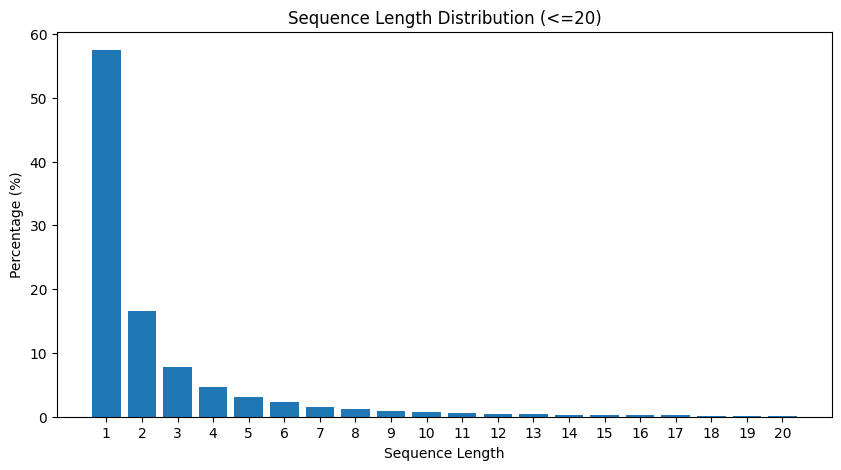

Length 1: 125222
Length 2: 36053
Length 3: 16925
Length 4: 10021
Length 5: 6764
Length 6: 4896
Length 7: 3457
Length 8: 2584
Length 9: 2031
Length 10: 1556
Length 11: 1220
Length 12: 964
Length 13: 871
Length 14: 716
Length 15: 559
Length 16: 505
Length 17: 422
Length 18: 345
Length 19: 290
Length 20: 275
Length 21: 250
Length 22: 209
Length 23: 176
Length 24: 137
Length 25: 141
Length 26: 122
Length 27: 102
Length 28: 80
Length 29: 80
Length 30: 65
Length 31: 69
Length 32: 52
Length 33: 53
Length 34: 47
Length 35: 40
Length 36: 35
Length 37: 40
Length 38: 36
Length 39: 17
Length 40: 28
Length 41: 25
Length 42: 28
Length 43: 16
Length 44: 18
Length 45: 17
Length 46: 18
Length 47: 13
Length 48: 17
Length 49: 19
Length 50: 13
Length 51: 7
Length 52: 10
Length 53: 15
Length 54: 7
Length 55: 8
Length 56: 8
Length 57: 8
Length 58: 10
Length 59: 4
Length 60: 5
Length 61: 5
Length 62: 6
Length 63: 4
Length 64: 5
Length 65: 4
Length 66: 8
Length 67: 3
Length 68: 3
Length 69: 3
Length 70: 4
Len

In [45]:
import matplotlib.pyplot as plt

sequence_length_dist = {}
for l in test_loader.dataset.seq_lengths:
    if not int(l) in sequence_length_dist:
        sequence_length_dist[int(l)] = 1
    else:
        sequence_length_dist[int(l)] += 1

lengths = sorted(sequence_length_dist.keys())
counts = [sequence_length_dist[l] for l in lengths]

total = sum(sequence_length_dist.values())
percentages = [count / total * 100 for count in counts]

plt.figure(figsize=(10, 5))

# only show lengths up to 20
max_len = 20
filtered_lengths = [l for l in lengths if l <= max_len]
filtered_counts = [sequence_length_dist[l] for l in filtered_lengths]

plt.figure(figsize=(10, 5))

# only show lengths up to 20
max_len = 20
filtered_lengths = [l for l in lengths if l <= max_len]
filtered_counts = [sequence_length_dist[l] for l in filtered_lengths]

total = sum(sequence_length_dist.values())
filtered_percent = [c / total * 100 for c in filtered_counts]

plt.bar(filtered_lengths, filtered_percent)

plt.xlabel("Sequence Length")
plt.ylabel("Percentage (%)")
plt.title("Sequence Length Distribution (<=20)")

plt.xticks(filtered_lengths)
plt.show()

for l in sorted(sequence_length_dist):
    print(f"Length {l}: {sequence_length_dist[l]}")


In [9]:
import inspect
import torch

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score,
    fbeta_score,
)

def compute_metrics_from_logits(y_true, logits, threshold=0.5):
    y_true = np.asarray(y_true).astype(np.int64)
    logits = np.asarray(logits, dtype=np.float32)

    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= threshold).astype(np.int64)

    metrics = {}

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, probs))
    except Exception:
        metrics["roc_auc"] = float("nan")

    try:
        metrics["pr_auc"] = float(average_precision_score(y_true, probs))
    except Exception:
        metrics["pr_auc"] = float("nan")

    metrics["accuracy"] = float(accuracy_score(y_true, preds))

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        preds,
        average="binary",
        zero_division=0,
    )

    metrics["precision"] = float(precision)
    metrics["recall"] = float(recall)
    metrics["f1"] = float(f1)
    metrics["f2"] = float(
        fbeta_score(y_true, preds, beta=2.0, average="binary", zero_division=0)
    )
    metrics["n"] = int(len(y_true))
    metrics["fraud_rate"] = float(y_true.mean())

    return metrics

def build_model_from_checkpoint(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    extra = ckpt.get("extra", {})

    model_class = extra.get("model_class")
    if model_class is None:
        raise ValueError(f"No model_class found in checkpoint extra for {checkpoint_path}")

    feature_dim = extra["feature_dim"]
    dropout = extra.get("dropout", 0.1)

    if model_class == "TransformerFraudModel":
        candidate_kwargs = {
            "feature_dim": feature_dim,
            "seq_len": extra.get("seq_len", 8),
            "d_model": extra.get("d_model", 64),
            "nhead": extra.get("nhead", 4),
            "num_layers": extra.get("num_layers", 3),
            "dim_feedforward": extra.get("dim_feedforward", 128),
            "dropout": dropout,
            "anomaly_checkpoint_path": extra.get("anomaly_checkpoint_path"),
            "freeze_anomaly_encoder": extra.get("freeze_anomaly_encoder", True),
            "include_ae_latent": extra.get("include_ae_latent", True),
            "include_ae_recon_error": extra.get("include_ae_recon_error", True),
            "include_ae_gates": extra.get("include_ae_gates", False),
        }
        cls = TransformerFraudModel

    elif model_class == "LastTokenMLP":
        candidate_kwargs = {
            "feature_dim": feature_dim,
            "hidden_dim": 64,
            "dropout": dropout,
            "anomaly_checkpoint_path": extra.get("anomaly_checkpoint_path"),
            "freeze_anomaly_encoder": extra.get("freeze_anomaly_encoder", True),
            "include_ae_latent": extra.get("include_ae_latent", True),
            "include_ae_recon_error": extra.get("include_ae_recon_error", True),
            "include_ae_gates": extra.get("include_ae_gates", False),
        }
        cls = LastTokenMLP

    else:
        raise ValueError(f"Unsupported model_class: {model_class}")

    # only pass kwargs the current constructor actually supports
    sig = inspect.signature(cls.__init__)
    filtered_kwargs = {k: v for k, v in candidate_kwargs.items() if k in sig.parameters}

    model = cls(**filtered_kwargs).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model, ckpt, extra

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_logits = []
    all_labels = []
    all_seq_lens = []

    cursor = 0
    seq_lengths = loader.dataset.seq_lengths

    for batch in loader:
        x = batch["x"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        y = batch["y"].cpu().numpy()

        logits = model(x, attention_mask).detach().cpu().numpy()

        batch_size = len(y)
        batch_seq_lens = seq_lengths[cursor:cursor + batch_size]
        cursor += batch_size

        all_logits.append(logits)
        all_labels.append(y)
        all_seq_lens.extend([int(s) for s in batch_seq_lens])

    all_logits = np.concatenate(all_logits)
    all_labels = np.concatenate(all_labels)
    all_seq_lens = np.asarray(all_seq_lens, dtype=np.int64)

    return {
        "logits": all_logits,
        "labels": all_labels,
        "seq_lens": all_seq_lens,
    }

def evaluate_prediction_dict(pred_dict, threshold=0.5):
    return compute_metrics_from_logits(
        y_true=pred_dict["labels"],
        logits=pred_dict["logits"],
        threshold=threshold,
    )


def evaluate_by_exact_length(pred_dict, threshold=0.5, min_count=50):
    labels = pred_dict["labels"]
    logits = pred_dict["logits"]
    seq_lens = pred_dict["seq_lens"]

    results = {}

    for L in sorted(np.unique(seq_lens)):
        mask = seq_lens == L
        n = int(mask.sum())
        if n < min_count:
            continue

        results[int(L)] = compute_metrics_from_logits(
            y_true=labels[mask],
            logits=logits[mask],
            threshold=threshold,
        )

    return results


def evaluate_by_buckets(pred_dict, buckets, threshold=0.5):
    """
    buckets example:
    {
        "len=1": lambda s: s == 1,
        "len=2": lambda s: s == 2,
        "len=3-4": lambda s: (s >= 3) & (s <= 4),
        "len=5-8": lambda s: (s >= 5) & (s <= 8),
        "len>=9": lambda s: s >= 9,
    }
    """
    labels = pred_dict["labels"]
    logits = pred_dict["logits"]
    seq_lens = pred_dict["seq_lens"]

    results = {}

    for name, fn in buckets.items():
        mask = fn(seq_lens)
        if mask.sum() == 0:
            continue

        results[name] = compute_metrics_from_logits(
            y_true=labels[mask],
            logits=logits[mask],
            threshold=threshold,
        )

    return results

def print_metrics(title, metrics):
    print(f"\n{title}")
    for k in ["n", "fraud_rate", "pr_auc", "roc_auc", "f2", "f1", "precision", "recall", "accuracy"]:
        if k in metrics:
            print(f"{k:>10s}: {metrics[k]:.4f}" if isinstance(metrics[k], float) else f"{k:>10s}: {metrics[k]}")

In [10]:
device = get_device()
THRESHOLD = 0.5

transformer_ckpt_path = "checkpoints/Transformer_AE_V3/best.pt"
mlp_ckpt_path = "checkpoints/MLP_baseline/best.pt"

transformer_model, transformer_ckpt, transformer_extra = build_model_from_checkpoint(
    transformer_ckpt_path, device
)

mlp_model, mlp_ckpt, mlp_extra = build_model_from_checkpoint(
    mlp_ckpt_path, device
)

print("Loaded transformer:", transformer_extra.get("model_class"), transformer_ckpt_path)
print("Loaded MLP:", mlp_extra.get("model_class"), mlp_ckpt_path)

transformer_preds = collect_predictions(transformer_model, test_loader, device)
mlp_preds = collect_predictions(mlp_model, test_loader, device)

transformer_overall = evaluate_prediction_dict(transformer_preds, threshold=THRESHOLD)
mlp_overall = evaluate_prediction_dict(mlp_preds, threshold=THRESHOLD)

print_metrics("Transformer overall", transformer_overall)
print_metrics("MLP overall", mlp_overall)

c:\Users\mengt\Documents\DeepLearning\DL_project\Models\FraudModel.py:204: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.sequence_encoder = nn.TransformerEncoder(


Loaded transformer: TransformerFraudModel checkpoints/Transformer_AE_V3/best.pt
Loaded MLP: LastTokenMLP checkpoints/MLP_baseline/best.pt

Transformer overall
         n: 58779
fraud_rate: 0.0372
    pr_auc: 0.4707
   roc_auc: 0.8567
        f2: 0.4646
        f1: 0.3144
 precision: 0.2043
    recall: 0.6819
  accuracy: 0.8894

MLP overall
         n: 58779
fraud_rate: 0.0372
    pr_auc: 0.4515
   roc_auc: 0.8591
        f2: 0.4702
        f1: 0.3351
 precision: 0.2266
    recall: 0.6430
  accuracy: 0.9051


In [11]:
length_buckets = {
    "len=1": lambda s: s == 1,
    "len=2": lambda s: s == 2,
    "len=3-4": lambda s: (s >= 3) & (s <= 4),
    "len=5-8": lambda s: (s >= 5) & (s <= 8),
    "len>=9": lambda s: s >= 9,
}

transformer_bucket_metrics = evaluate_by_buckets(
    transformer_preds, length_buckets, threshold=THRESHOLD
)

mlp_bucket_metrics = evaluate_by_buckets(
    mlp_preds, length_buckets, threshold=THRESHOLD
)

for bucket_name in length_buckets:
    if bucket_name in transformer_bucket_metrics:
        print_metrics(f"Transformer - {bucket_name}", transformer_bucket_metrics[bucket_name])
    if bucket_name in mlp_bucket_metrics:
        print_metrics(f"MLP - {bucket_name}", mlp_bucket_metrics[bucket_name])


Transformer - len=1
         n: 33684
fraud_rate: 0.0370
    pr_auc: 0.4978
   roc_auc: 0.8777
        f2: 0.4796
        f1: 0.3245
 precision: 0.2109
    recall: 0.7039
  accuracy: 0.8916

MLP - len=1
         n: 33684
fraud_rate: 0.0370
    pr_auc: 0.4753
   roc_auc: 0.8778
        f2: 0.4860
        f1: 0.3464
 precision: 0.2342
    recall: 0.6645
  accuracy: 0.9072

Transformer - len=2
         n: 9689
fraud_rate: 0.0377
    pr_auc: 0.4467
   roc_auc: 0.8291
        f2: 0.4566
        f1: 0.3060
 precision: 0.1975
    recall: 0.6795
  accuracy: 0.8839

MLP - len=2
         n: 9689
fraud_rate: 0.0377
    pr_auc: 0.4275
   roc_auc: 0.8355
        f2: 0.4481
        f1: 0.3147
 precision: 0.2103
    recall: 0.6247
  accuracy: 0.8975

Transformer - len=3-4
         n: 7321
fraud_rate: 0.0380
    pr_auc: 0.4685
   roc_auc: 0.8416
        f2: 0.4362
        f1: 0.2939
 precision: 0.1904
    recall: 0.6439
  accuracy: 0.8825

MLP - len=3-4
         n: 7321
fraud_rate: 0.0380
    pr_auc:

In [52]:
transformer_exact = evaluate_by_exact_length(transformer_preds, threshold=THRESHOLD, min_count=100)
mlp_exact = evaluate_by_exact_length(mlp_preds, threshold=THRESHOLD, min_count=100)

print("\nExact-length comparison (min_count=100)")
for L in sorted(set(transformer_exact.keys()) | set(mlp_exact.keys())):
    print(f"\nLength {L}")
    if L in transformer_exact:
        print(f"  Transformer: pr_auc={transformer_exact[L]['pr_auc']:.4f}, "
              f"f2={transformer_exact[L]['f2']:.4f}, "
              f"recall={transformer_exact[L]['recall']:.4f}, "
              f"n={transformer_exact[L]['n']}")
    if L in mlp_exact:
        print(f"  MLP        : pr_auc={mlp_exact[L]['pr_auc']:.4f}, "
              f"f2={mlp_exact[L]['f2']:.4f}, "
              f"recall={mlp_exact[L]['recall']:.4f}, "
              f"n={mlp_exact[L]['n']}")


Exact-length comparison (min_count=100)

Length 1
  Transformer: pr_auc=0.4964, f2=0.5061, recall=0.6356, n=33684
  MLP        : pr_auc=0.4753, f2=0.4860, recall=0.6645, n=33684

Length 2
  Transformer: pr_auc=0.4433, f2=0.4667, recall=0.5945, n=9689
  MLP        : pr_auc=0.4275, f2=0.4481, recall=0.6247, n=9689

Length 3
  Transformer: pr_auc=0.4577, f2=0.4511, recall=0.5614, n=4528
  MLP        : pr_auc=0.4421, f2=0.4177, recall=0.5731, n=4528

Length 4
  Transformer: pr_auc=0.4554, f2=0.4939, recall=0.6075, n=2793
  MLP        : pr_auc=0.4211, f2=0.4712, recall=0.6262, n=2793

Length 5
  Transformer: pr_auc=0.3698, f2=0.4598, recall=0.6275, n=1849
  MLP        : pr_auc=0.2961, f2=0.4101, recall=0.6078, n=1849

Length 6
  Transformer: pr_auc=0.4928, f2=0.4938, recall=0.6038, n=1345
  MLP        : pr_auc=0.5114, f2=0.5286, recall=0.6981, n=1345

Length 7
  Transformer: pr_auc=0.5090, f2=0.4978, recall=0.5750, n=955
  MLP        : pr_auc=0.4558, f2=0.4864, recall=0.6250, n=955

Length

Best Transformer: {'threshold': np.float64(0.6831313131313131), 'precision': 0.34413965087281795, 'recall': 0.5684210526315789, 'f1': 0.4287193648602002, 'f2': 0.5028747266985181}
Best MLP: {'threshold': np.float64(0.594040404040404), 'precision': 0.2802209944751381, 'recall': 0.5803203661327231, 'f1': 0.37794336810730256, 'f2': 0.4779494911421033}
Best Ensemble (prob blend): {'alpha': 0.65, 'blend_mode': 'prob', 'threshold': 0.6237373737373737, 'precision': 0.3117816091954023, 'recall': 0.5958810068649886, 'f1': 0.40936959597547556, 'f2': 0.5040260142458965}
Best Ensemble (logit blend): {'alpha': 0.9, 'blend_mode': 'logit', 'threshold': 0.6732323232323232, 'precision': 0.33994565217391304, 'recall': 0.5725400457665903, 'f1': 0.4265984654731458, 'f2': 0.5036231884057971}

Best probability-blend result per alpha:
alpha=0.00  threshold=0.59  f2=0.4779  precision=0.2802  recall=0.5803
alpha=0.05  threshold=0.59  f2=0.4797  precision=0.2828  recall=0.5808
alpha=0.10  threshold=0.63  f2=0.4

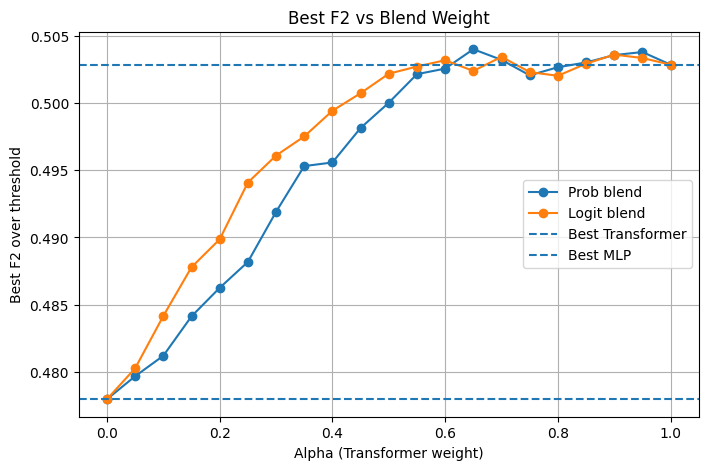

In [13]:
# Run threshold sweep
import matplotlib.pyplot as plt

def threshold_sweep(pred_dict, thresholds=np.linspace(0.01, 0.99, 50)):
    y_true = pred_dict["labels"]
    logits = pred_dict["logits"]

    probs = 1 / (1 + np.exp(-logits))

    results = []

    for t in thresholds:
        preds = (probs >= t).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, preds, average="binary", zero_division=0
        )

        f2 = fbeta_score(
            y_true, preds, beta=2.0, average="binary", zero_division=0
        )

        results.append({
            "threshold": t,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2
        })

    return results

def threshold_sweep_ensemble(
    pred_dict_mlp,
    pred_dict_trans,
    alpha=0.7,
    thresholds=np.linspace(0.01, 0.99, 50),
    blend_mode="prob",
):
    y_true = pred_dict_mlp["labels"]
    logits_mlp = pred_dict_mlp["logits"]
    logits_trans = pred_dict_trans["logits"]

    if blend_mode == "prob":
        probs_mlp = 1 / (1 + np.exp(-logits_mlp))
        probs_trans = 1 / (1 + np.exp(-logits_trans))
        probs = alpha * probs_trans + (1 - alpha) * probs_mlp

    elif blend_mode == "logit":
        blended_logits = alpha * logits_trans + (1 - alpha) * logits_mlp
        probs = 1 / (1 + np.exp(-blended_logits))

    else:
        raise ValueError(f"Unsupported blend_mode: {blend_mode}")

    results = []

    for t in thresholds:
        preds = (probs >= t).astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, preds, average="binary", zero_division=0
        )

        f2 = fbeta_score(
            y_true, preds, beta=2.0, average="binary", zero_division=0
        )

        results.append({
            "alpha": float(alpha),
            "blend_mode": blend_mode,
            "threshold": float(t),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "f2": float(f2),
        })

    return results

def blend_weight_sweep(
    pred_dict_mlp,
    pred_dict_trans,
    alphas=np.linspace(0.0, 1.0, 11),
    thresholds=np.linspace(0.01, 0.99, 50),
    blend_mode="prob",
):
    all_results = []

    for alpha in alphas:
        sweep = threshold_sweep_ensemble(
            pred_dict_mlp=pred_dict_mlp,
            pred_dict_trans=pred_dict_trans,
            alpha=alpha,
            thresholds=thresholds,
            blend_mode=blend_mode,
        )
        all_results.extend(sweep)

    return all_results

def get_best_by_metric(sweep_results, metric="f2"):
    return max(sweep_results, key=lambda x: x[metric])


thresholds = np.linspace(0.01, 0.99, 100)
alphas = np.linspace(0.0, 1.0, 21)  # finer sweep: 0.00, 0.05, ..., 1.00

transformer_sweep = threshold_sweep(transformer_preds, thresholds=thresholds)
mlp_sweep = threshold_sweep(mlp_preds, thresholds=thresholds)

ensemble_prob_sweep = blend_weight_sweep(
    pred_dict_mlp=mlp_preds,
    pred_dict_trans=transformer_preds,
    alphas=alphas,
    thresholds=thresholds,
    blend_mode="prob",
)

ensemble_logit_sweep = blend_weight_sweep(
    pred_dict_mlp=mlp_preds,
    pred_dict_trans=transformer_preds,
    alphas=alphas,
    thresholds=thresholds,
    blend_mode="logit",
)

best_transformer = get_best_by_metric(transformer_sweep, "f2")
best_mlp = get_best_by_metric(mlp_sweep, "f2")
best_ensemble_prob = get_best_by_metric(ensemble_prob_sweep, "f2")
best_ensemble_logit = get_best_by_metric(ensemble_logit_sweep, "f2")

print("Best Transformer:", best_transformer)
print("Best MLP:", best_mlp)
print("Best Ensemble (prob blend):", best_ensemble_prob)
print("Best Ensemble (logit blend):", best_ensemble_logit)

def best_per_alpha(sweep_results, metric="f2"):
    grouped = {}

    for row in sweep_results:
        alpha = row["alpha"]
        if alpha not in grouped or row[metric] > grouped[alpha][metric]:
            grouped[alpha] = row

    return [grouped[a] for a in sorted(grouped.keys())]

best_prob_per_alpha = best_per_alpha(ensemble_prob_sweep, metric="f2")
best_logit_per_alpha = best_per_alpha(ensemble_logit_sweep, metric="f2")

print("\nBest probability-blend result per alpha:")
for row in best_prob_per_alpha:
    print(
        f"alpha={row['alpha']:.2f}  "
        f"threshold={row['threshold']:.2f}  "
        f"f2={row['f2']:.4f}  "
        f"precision={row['precision']:.4f}  "
        f"recall={row['recall']:.4f}"
    )

print("\nBest logit-blend result per alpha:")
for row in best_logit_per_alpha:
    print(
        f"alpha={row['alpha']:.2f}  "
        f"threshold={row['threshold']:.2f}  "
        f"f2={row['f2']:.4f}  "
        f"precision={row['precision']:.4f}  "
        f"recall={row['recall']:.4f}"
    )

def plot_metric(sweep, label, metric="f2"):
    thresholds = [x["threshold"] for x in sweep]
    values = [x[metric] for x in sweep]
    plt.plot(thresholds, values, label=label)


plt.figure(figsize=(8, 5))

plt.plot(
    [row["alpha"] for row in best_prob_per_alpha],
    [row["f2"] for row in best_prob_per_alpha],
    marker="o",
    label="Prob blend",
)

plt.plot(
    [row["alpha"] for row in best_logit_per_alpha],
    [row["f2"] for row in best_logit_per_alpha],
    marker="o",
    label="Logit blend",
)

plt.axhline(best_transformer["f2"], linestyle="--", label="Best Transformer")
plt.axhline(best_mlp["f2"], linestyle="--", label="Best MLP")

plt.xlabel("Alpha (Transformer weight)")
plt.ylabel("Best F2 over threshold")
plt.title("Best F2 vs Blend Weight")
plt.legend()
plt.grid(True)
plt.show()

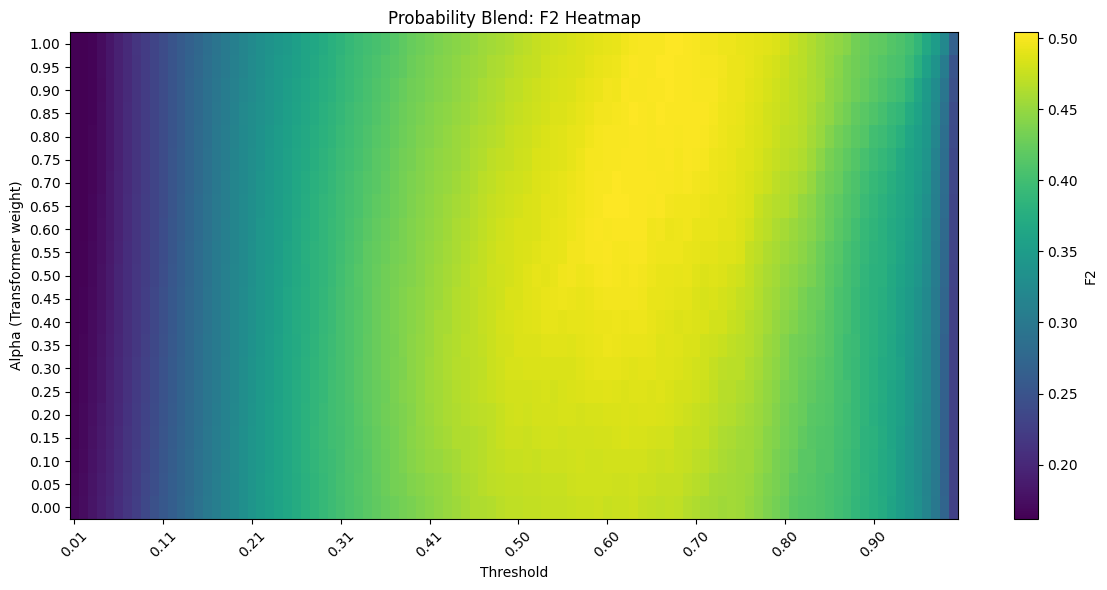

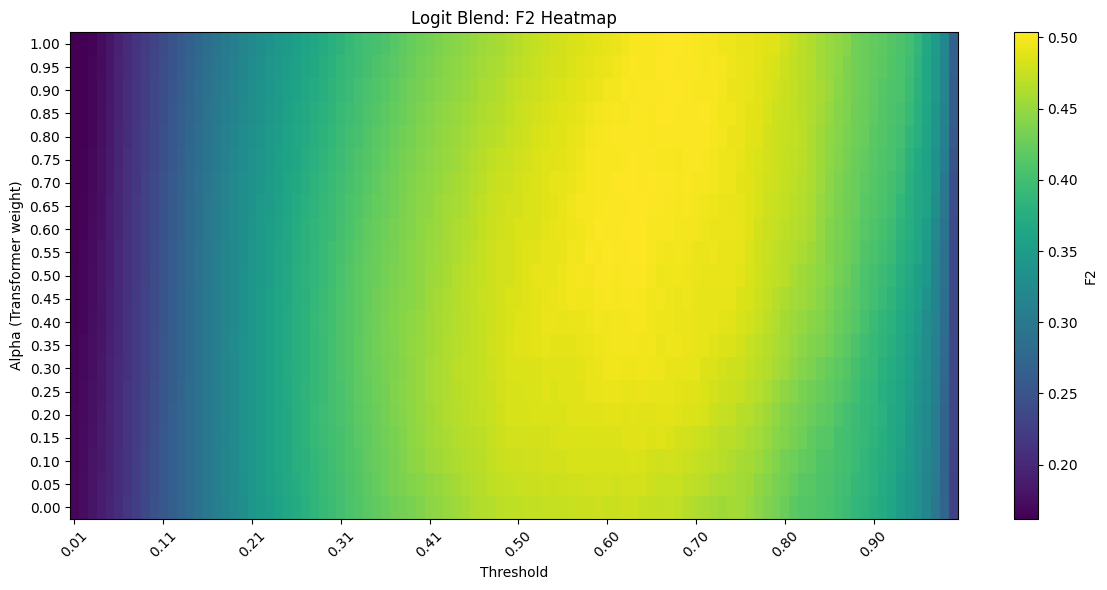

In [14]:
import pandas as pd

def plot_alpha_threshold_heatmap(sweep_results, title="F2 Heatmap"):
    df = pd.DataFrame(sweep_results)
    pivot = df.pivot(index="alpha", columns="threshold", values="f2")

    plt.figure(figsize=(12, 6))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label="F2")

    plt.yticks(range(len(pivot.index)), [f"{a:.2f}" for a in pivot.index])
    x_positions = range(0, len(pivot.columns), max(1, len(pivot.columns)//10))
    plt.xticks(x_positions, [f"{pivot.columns[i]:.2f}" for i in x_positions], rotation=45)

    plt.xlabel("Threshold")
    plt.ylabel("Alpha (Transformer weight)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_alpha_threshold_heatmap(ensemble_prob_sweep, title="Probability Blend: F2 Heatmap")
plot_alpha_threshold_heatmap(ensemble_logit_sweep, title="Logit Blend: F2 Heatmap")